# 02 · Policy comparison and decision economics

## Context & methods
A chronological holdout compares manual processing, checks, and checks plus a calibrated probability. The threshold is fixed on validation data before this period. Values below are recomputed from the saved run; costs and time are scenario assumptions.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT))
plt.rcParams.update({'figure.figsize':(10,4.5),'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
summary=pd.read_csv(ROOT/'results/policy_summary.csv')
run=json.loads((ROOT/'results/run_summary.json').read_text())
scored=pd.read_csv(ROOT/'results/scored_claims.csv',dtype={'procedure_code':str})


## Results · throughput is not net value

In [2]:
display(summary.round(3))
print('Threshold:',round(run['threshold'],3), '| Holdout:',run['holdout_start'],'to',run['holdout_end'])

,policy,n_claims,auto_approved,reviewed,wrong_approvals,auto_rate,wrong_auto_rate,wrong_rate_low,wrong_rate_high,wrong_per_1000,gross_review_savings,automation_cost,wrong_approval_loss,net_cost,net_savings,handling_hours,mean_turnaround_hours
0,Manual,6627,0,6627,0,0.000,NaN,NaN,NaN,0.000,0.0,0.00,0.00,119286.00,0.00,1325.400,24.200
1,Checks,6627,5858,769,159,0.884,0.027,0.023,0.032,23.993,105444.0,2050.30,46631.34,62523.64,56762.36,178.208,2.812
2,Checks + score,6627,5123,1504,59,0.773,0.012,0.009,0.015,8.903,92214.0,1793.05,17227.15,46092.20,73193.80,322.146,5.495


Threshold: 0.955 | Holdout: 2026-02-01 00:09:11 to 2026-06-30 23:27:48


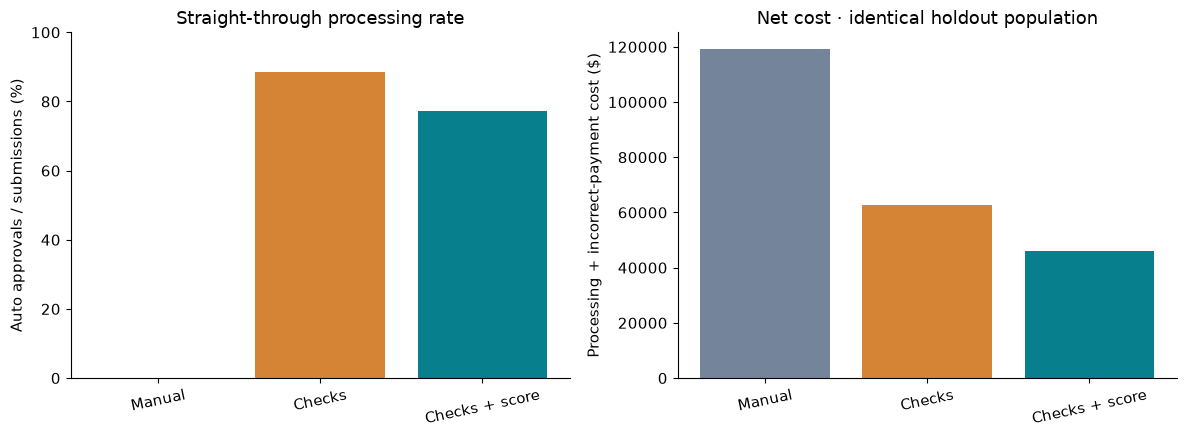

In [3]:
colors=['#73849b','#d58435','#087f8c']
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].bar(summary.policy,summary.auto_rate*100,color=colors); axes[0].set(ylabel='Auto approvals / submissions (%)',title='Straight-through processing rate',ylim=(0,100))
axes[1].bar(summary.policy,summary.net_cost,color=colors); axes[1].set(ylabel='Processing + incorrect-payment cost ($)',title='Net cost · identical holdout population')
for ax in axes: ax.tick_params(axis='x',rotation=12)
plt.tight_layout(); plt.show()


### Net savings independently recomputed

In [4]:
from src.evaluate import decision
h=scored[scored.split.eq('holdout')].copy(); c=run['config']
auto=decision(h,'Checks + score',run['threshold']); wrong=auto&~h.payable
gross=auto.sum()*c['review_cost']; auto_cost=auto.sum()*c['auto_cost']
loss=wrong.sum()*c['wrong_approval_cost']+h.loc[wrong,'scheduled_payment'].sum()*c['payment_loss_multiplier']
net=gross-auto_cost-loss
assert abs(net-summary.iloc[2].net_savings)<1e-6
display(pd.DataFrame({'component':['Avoided review cost','Automatic processing cost','Wrong-approval loss','Net savings'],'USD':[gross,-auto_cost,-loss,net]}).round(2))
print('Conditional provider-bootstrap 95% interval:',run['net_savings_provider_bootstrap_95'])


,component,USD
0,Avoided review cost,92214.00
1,Automatic processing cost,-1793.05
2,Wrong-approval loss,-17227.15
3,Net savings,73193.80


Conditional provider-bootstrap 95% interval: [65263.98074999999, 80923.12299999999]


### Calibration and drift
The calibration step is fitted only in Oct–Nov 2025. Compare raw and calibrated Brier scores explicitly; lower is better. The holdout contains a predeclared 35% error-incidence stress.

,brier_raw,brier_calibrated,log_loss,roc_auc,ece
0,0.038549,0.038991,0.150399,0.86158,0.017455


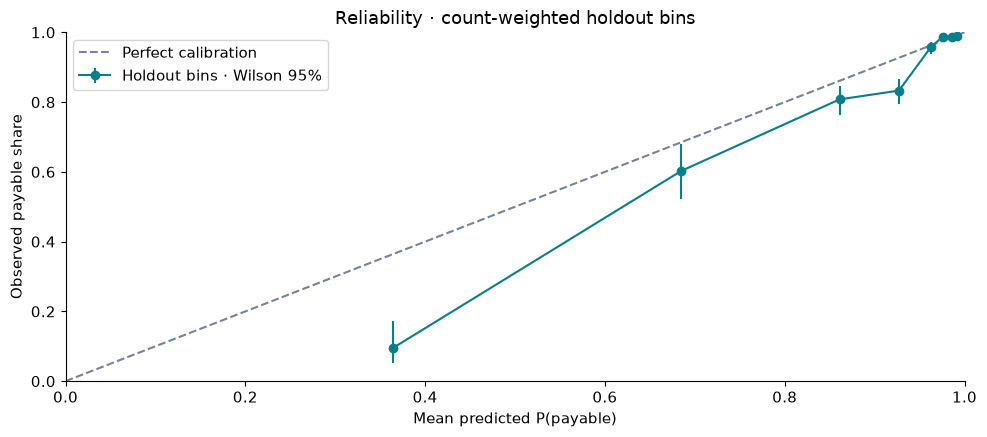

,bin,n,mean_predicted,observed_payable,observed_low,observed_high
0,"(-0.001, 0.5]",94,0.3646,0.0957,0.0512,0.1720
1,"(0.5, 0.8]",146,0.6849,0.6027,0.5217,0.6785
2,"(0.8, 0.9]",359,0.8610,0.8078,0.7639,0.8452
3,"(0.9, 0.95]",443,0.9271,0.8330,0.7954,0.8648
4,"(0.95, 0.97]",538,0.9625,0.9572,0.9367,0.9713
5,"(0.97, 0.98]",1063,0.9759,0.9878,0.9792,0.9928
6,"(0.98, 0.99]",3360,0.9856,0.9854,0.9808,0.9890
7,"(0.99, 1.0]",624,0.9913,0.9888,0.9770,0.9946


In [5]:
display(pd.DataFrame([{k:run[k] for k in ['brier_raw','brier_calibrated','log_loss','roc_auc','ece']}]))
reliability=pd.read_csv(ROOT/'results/calibration.csv')
fig,ax=plt.subplots(); ax.plot([0,1],[0,1],'--',color='#73849b',label='Perfect calibration')
ax.errorbar(reliability.mean_predicted,reliability.observed_payable,yerr=[reliability.observed_payable-reliability.observed_low,reliability.observed_high-reliability.observed_payable],fmt='o-',color='#087f8c',label='Holdout bins · Wilson 95%')
ax.set(xlabel='Mean predicted P(payable)',ylabel='Observed payable share',title='Reliability · count-weighted holdout bins',xlim=(0,1),ylim=(0,1)); ax.legend(); plt.tight_layout(); plt.show()
display(reliability.round(4))


### Economic sensitivity
Holdout curves are descriptive and do not reselect the reported threshold. Review cost and wrong-approval remediation costs are assumptions; scheduled payment loss is added separately.

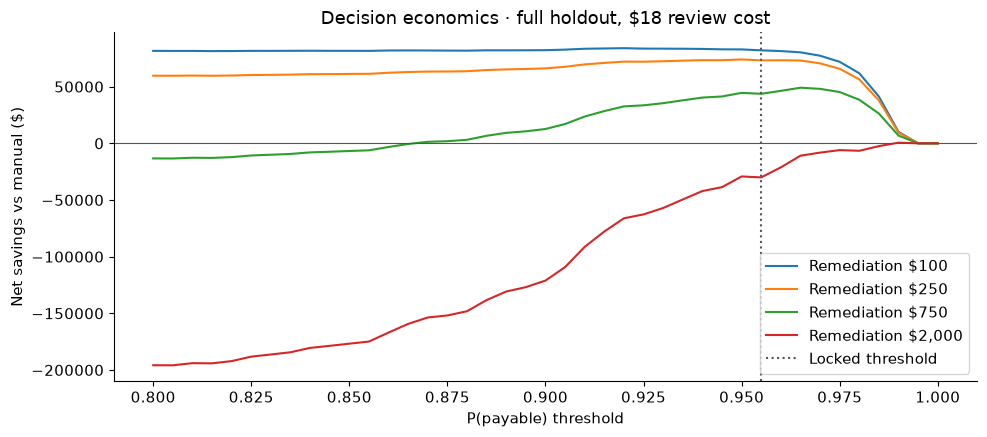

In [6]:
s=pd.read_csv(ROOT/'results/sensitivity.csv')
fig,ax=plt.subplots()
for penalty in [100,250,750,2000]:
    g=s[(s.policy=='Checks + score')&(s.review_cost==18)&(s.wrong_approval_cost==penalty)].sort_values('threshold')
    ax.plot(g.threshold,g.net_savings,label=f'Remediation ${penalty:,}')
ax.axvline(run['threshold'],color='#555',ls=':',label='Locked threshold'); ax.axhline(0,color='#555',lw=.8)
ax.set(xlabel='P(payable) threshold',ylabel='Net savings vs manual ($)',title='Decision economics · full holdout, $18 review cost'); ax.legend(); plt.tight_layout(); plt.show()


### Legitimate exceptions and workload over time

,event_type,n_claims,auto_approved,reviewed,wrong_approvals,net_savings
20,billing_anomaly,40,1,39,1,-304.23
21,correction,146,0,146,0,0.00
22,coverage_failure,74,1,73,1,-304.23
23,documentation_resolved,161,0,161,0,0.00
24,duplicate,88,0,88,0,0.00
25,legitimate_unusual,261,180,81,0,3177.00
26,medical_necessity_failure,139,54,85,54,-14798.07
27,repeat_therapy,187,0,187,0,0.00
28,routine,5494,4884,610,0,86202.60
29,unresolved_documentation,37,3,34,3,-779.27


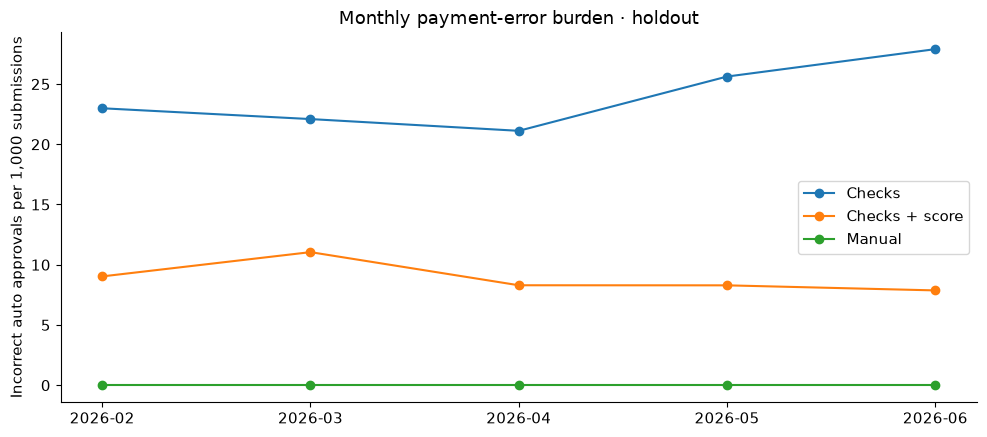

In [7]:
segments=pd.read_csv(ROOT/'results/segments.csv')
display(segments[segments.policy.eq('Checks + score')][['event_type','n_claims','auto_approved','reviewed','wrong_approvals','net_savings']].round(2))
monthly=pd.read_csv(ROOT/'results/monthly.csv'); fig,ax=plt.subplots()
for policy,g in monthly.groupby('policy'):
    ax.plot(g.month,g.wrong_per_1000,marker='o',label=policy)
ax.set(ylabel='Incorrect auto approvals per 1,000 submissions',title='Monthly payment-error burden · holdout'); ax.legend(); plt.tight_layout(); plt.show()


## Takeaways
Checks plus score trades some automatic throughput for fewer incorrect payments and higher net savings at the default settings. The decision can change when loss assumptions rise. Calibration slightly worsens holdout Brier score, so recalibration and prospective validation are required before operational use. Review is not denial; valid unusual claims retain their payable outcome. Fixed queues, perfect manual adjudication and common historical feedback constrain interpretation. See [full methods and limitations](../docs/METHODS.md).